In [50]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

# Define the PINN model
class PINN(nn.Module):
    num_neurons: int
    num_layers: int

    @nn.compact
    def __call__(self, x):
        for _ in range(self.num_layers - 1):
            x = jnp.sin(nn.Dense(features=self.num_neurons)(x))
            # x = nn.tanh(nn.Dense(features=self.num_neurons)(x))
        x = nn.Dense(features=1)(x)
        return x

class PINNPoly(nn.Module):
    degree: int  # The degree of the polynomial

    @nn.compact
    def __call__(self, x):
        # Initialize trainable coefficients for the polynomial
        coefficients = self.param('coefficients', nn.initializers.zeros, (self.degree + 1,))
        
        # Compute the polynomial f(x) = a_0 + a_1*x + a_2*x^2 + ... + a_n*x^n
        powers = jnp.arange(self.degree + 1)  # [0, 1, ..., degree]
        polynomial_terms = coefficients * jnp.power(x, powers)
        return jnp.sum(polynomial_terms, axis=-1)  # Sum up all terms to get f(x)

        
# Define the forcing function f(x) (this is the negative)
def forcing_function(x):
    return 36 * jnp.sin(6 * x)

def true(x): 
    return jnp.sin(6 * x)

# Define the loss function
def loss_fn(params, model, x_physics, x_boundary):
    # Physics loss (residual of the PDE)
    def residual(x):
        def u(x_):
            return jnp.squeeze(model.apply({'params': params}, x_))
        u_xx = jax.jacfwd(
                jax.jacrev(u)
        )(x)
        return u_xx + forcing_function(x)
    residual_values = jax.vmap(residual)(x_physics)
    physics_loss = jnp.mean(residual_values**2)

    # Boundary loss (Dirichlet bc)
    u_pred_boundary = jax.vmap(lambda x_: model.apply({'params': params}, x_))(x_boundary)
    boundary_loss = jnp.mean(u_pred_boundary**2)

    return physics_loss + boundary_loss

In [51]:
def generate_nonuniform_dataset(n: int = 65):
    # i) 10000 evenly-spaced points in the range [-pi, pi]
    # In Pinns, don't want endpoints
    large_dataset = jnp.linspace(-jnp.pi, jnp.pi, 10000)[1:-1]

    # ii) Select 20 points that minimize |sin(x) - sin(6x)|
    diff1 = jnp.abs(jnp.sin(large_dataset) - jnp.sin(6 * large_dataset))
    indices1 = jnp.argsort(diff1)[:25]
    selected_points1 = large_dataset[indices1]

    # Create a boolean mask to exclude the already selected points
    mask = jnp.ones(large_dataset.shape, dtype=bool)
    mask = mask.at[indices1].set(False)
    remaining_dataset = large_dataset[mask]

    # Calculate the differences for the remaining dataset
    diff2_remaining = jnp.abs(jnp.sin(2 * remaining_dataset) - jnp.sin(6 * remaining_dataset))
    indices2_remaining = jnp.argsort(diff2_remaining)[:20]
    selected_points2 = remaining_dataset[indices2_remaining]

    # iii) Combine these 30 points with n - 30 uniformly selected points
    num_uniform = n - 45
    uniform_points = jnp.linspace(-jnp.pi, jnp.pi, num_uniform + 2)[1:-1]
    training_data = jnp.sort(
        jnp.concatenate([selected_points1, selected_points2, uniform_points])
    )
    return training_data.reshape((-1, 1))

def generate_test_dataset():
    return jnp.linspace(-jnp.pi, jnp.pi, 1000).reshape((-1, 1))


In [71]:
def train_pinns(x_physics, x_test, epochs: int=100):
    # Initialize the PINN model
    key = jax.random.PRNGKey(0)
    model = PINN(num_neurons=32, num_layers=4)
    # model = PINNPoly(degree=16)
    params = model.init(key, jnp.array([1]))['params']
    scaled_params = jax.tree.map(lambda p: p * 6, params)
    
    # Define the training step
    @jax.jit
    def train_step(params, opt_state, x_physics, x_boundary):
        grad_fn = jax.value_and_grad(loss_fn)
        loss, grads = grad_fn(params, model, x_physics, x_boundary)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss

    @jax.jit
    def eval_u(params, x_physics):
        # First evaluate the loss 
        loss = loss_fn(params, model, x_physics, jnp.array([[-jnp.pi], [jnp.pi]]))
        
        # Then evaluate the true 
        error = jnp.mean(
            (model.apply({'params': params}, x_physics) -  true(x_physics)) ** 2
        )
        return loss, error  
    
    # Initialize the optimizer
    learning_rate = 1e-4
    # learning_rate = 5e-5
    # learning_rate = 1e-2
    # optimizer = optax.sgd(learning_rate)
    optimizer = optax.adam(learning_rate)
    opt_state = optimizer.init(params)
    
    # Boundary points     
    x_boundary = jnp.array([[-jnp.pi], [jnp.pi]])

    # Training loop
    train_losses = []
    train_errors = []
    test_losses = []
    test_errors = []
    all_params = []
    for epoch in tqdm(range(epochs)):
        params, opt_state, loss = train_step(params, opt_state, x_physics, x_boundary)
        
        tloss, terror = eval_u(params, x_physics)
        train_losses.append(tloss)
        train_errors.append(terror)
        tloss, terror = eval_u(params, x_test)
        test_losses.append(tloss)
        test_errors.append(terror)
        if epoch % 50 == 0:
            all_params.append(
                params
            )
        # if epoch % 100 == 0:
        #     print(f"Epoch {epoch}, Loss: {loss:.4e}")
            
    return {'train_losses': train_losses, 'train_errors': train_errors, 
            'test_losses': test_losses, 'test_errors': test_errors,
            'params': all_params, 'model': model}

In [72]:
train = generate_nonuniform_dataset(65)
test = generate_test_dataset()

out_65 = train_pinns(train, test, epochs=10000)


def generate_uniform_dataset(n: int = 1000):
    return jnp.linspace(-jnp.pi, jnp.pi, n).reshape((-1, 1))

train = generate_uniform_dataset(65)
test = generate_test_dataset()

out_100 = train_pinns(train, test, epochs=10000)


# train =  generate_nonuniform_dataset(1000)
# test = generate_test_dataset()

# out_1000 = train_pinns(train, test, epochs=800)


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

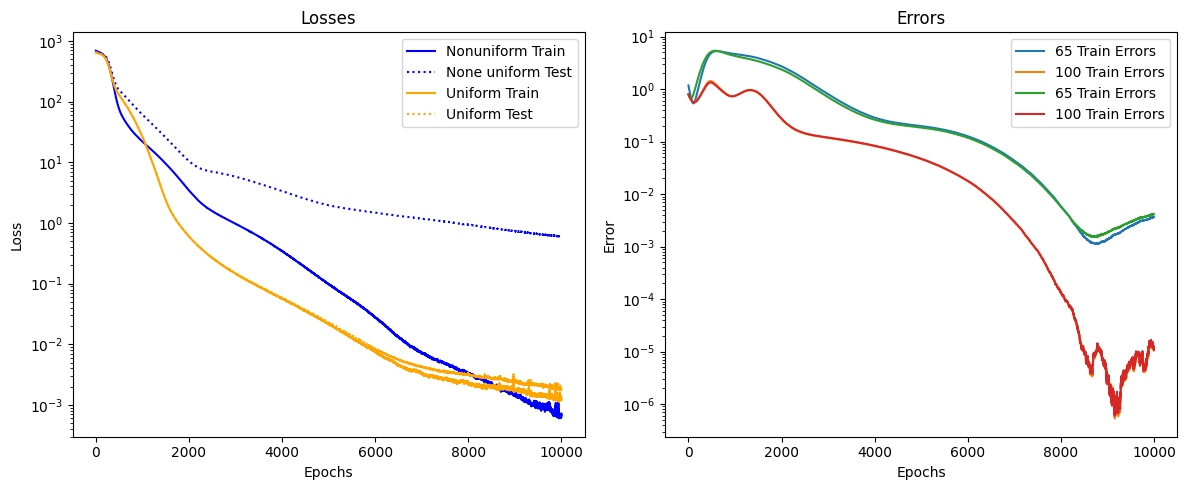

In [73]:
# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for losses
ax1.semilogy(out_65['train_losses'],color='blue', label='Nonuniform Train')
ax1.semilogy(out_65['test_losses'], color='blue',linestyle='dotted', label='None uniform Test')
ax1.semilogy(out_100['train_losses'], color='orange',label='Uniform Train')
ax1.semilogy(out_100['test_losses'], color='orange',linestyle='dotted', label='Uniform Test')
ax1.set_title('Losses')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Second subplot for errors
ax2.semilogy(out_65['train_errors'], label='65 Train Errors')
ax2.semilogy(out_100['train_errors'], label='100 Train Errors')
ax2.semilogy(out_65['test_errors'], label='65 Train Errors')
ax2.semilogy(out_100['test_errors'], label='100 Train Errors')

ax2.set_title('Errors')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Error')
ax2.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Evaluate for out_65
num_test_points = 200
x_test = jnp.linspace(-jnp.pi, jnp.pi, num_test_points).reshape(-1, 1)
u_analytical = true(x_test)

all_params = out_65['params'][0:]
for i, params in enumerate(all_params):
    u_pred = out_65['model'].apply({'params': params}, x_test)
    ax1.plot(x_test, u_pred, color='black', alpha=i / (len(all_params) + 3))

ax1.plot(x_test, u_analytical, '--', label='Analytical Solution')
train = generate_nonuniform_dataset(65)
ax1.plot(train, true(train), 'x')
ax1.set_xlabel('x')
ax1.set_ylabel('u(x)')
ax1.set_title('PINN Solution vs. Analytical Solution (Non-uni)')
ax1.grid(True)
# ax1.set_ylim((-3, 3))

# Evaluate for out_100
x_test = jnp.linspace(-jnp.pi, jnp.pi, num_test_points).reshape(-1, 1)
u_analytical = true(x_test)

all_params = out_100['params'][0:10]
for i, params in enumerate(all_params):
    u_pred = out_100['model'].apply({'params': params}, x_test)
    ax2.plot(x_test, u_pred, color='black', alpha=i / (len(all_params) + 3))

ax2.plot(x_test, u_analytical, '--', label='Analytical Solution')
train = generate_uniform_dataset(65)
ax2.plot(train, true(train), 'x')
ax2.set_xlabel('x')
ax2.set_ylabel('u(x)')
ax2.set_title('PINN Solution vs. Analytical Solution (Uni)')
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

## Quickly try u' = f

In [17]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# os.environ['JAX_PLATFORMS']='cpu'

import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

# Define the PINN model
class PINN(nn.Module):
    num_neurons: int
    num_layers: int

    @nn.compact
    def __call__(self, x):
        for _ in range(self.num_layers - 1):
            x = jnp.sin(nn.Dense(features=self.num_neurons)(x))
            # x = nn.tanh(nn.Dense(features=self.num_neurons)(x))
        x = nn.Dense(features=1)(x)
        return x

# Define the forcing function f(x)
def forcing_function(x):
    return 6 * jnp.cos(6 * x)

def true(x): 
    return jnp.sin(6 * x)

# Define the loss function
def loss_fn(params, model, x_physics, x_boundary):
    # Physics loss (residual of the PDE)
    def residual(x):
        def u(x_):
            return jnp.squeeze(model.apply({'params': params}, x_))
        u_x = jax.jacrev(u)(x)
        return u_x - forcing_function(x)
    residual_values = jax.vmap(residual)(x_physics)
    physics_loss = jnp.mean(residual_values**2)

    # Boundary loss (Dirichlet bc)
    u_pred_boundary = jax.vmap(lambda x_: model.apply({'params': params}, x_))(x_boundary)
    boundary_loss = jnp.mean(u_pred_boundary**2)

    return physics_loss + boundary_loss

In [23]:
def generate_nonuniform_dataset(n: int = 65):
    # i) 10000 evenly-spaced points in the range [-pi, pi]
    # In Pinns, don't want endpoints
    large_dataset = jnp.linspace(-jnp.pi, jnp.pi, 10000)[1:-1]

    
    
    # ii) Select 20 points that minimize |sin(x) - sin(6x)|
    # diff1 = jnp.abs(jnp.sin(large_dataset) - jnp.sin(6 * large_dataset))
    diff1 = jnp.abs(jnp.cos(large_dataset) - 6 * jnp.cos(6 * large_dataset))

    indices1 = jnp.argsort(diff1)[:20]
    selected_points1 = large_dataset[indices1]

    # Create a boolean mask to exclude the already selected points
    mask = jnp.ones(large_dataset.shape, dtype=bool)
    mask = mask.at[indices1].set(False)
    remaining_dataset = large_dataset[mask]

    # Calculate the differences for the remaining dataset
    diff2_remaining = jnp.abs(3 * jnp.cos(3 * remaining_dataset) - 6 * jnp.cos(6 * remaining_dataset))
    indices2_remaining = jnp.argsort(diff2_remaining)[:20]
    selected_points2 = remaining_dataset[indices2_remaining]

    # iii) Combine these 30 points with n - 30 uniformly selected points
    num_uniform = n - 40
    uniform_points = jnp.linspace(-jnp.pi, jnp.pi, num_uniform + 2)[1:-1]
    training_data = jnp.sort(
        jnp.concatenate([selected_points1, selected_points2, uniform_points])
    )
    return training_data.reshape((-1, 1))

def generate_test_dataset():
    return jnp.linspace(-jnp.pi, jnp.pi, 1000).reshape((-1, 1))


In [24]:
def train_pinns(x_physics, x_test, epochs: int=100):
    # Initialize the PINN model
    key = jax.random.PRNGKey(0)
    model = PINN(num_neurons=64, num_layers=6)
    params = model.init(key, jnp.array([1]))['params']
    
    # Define the training step
    @jax.jit
    def train_step(params, opt_state, x_physics, x_boundary):
        grad_fn = jax.value_and_grad(loss_fn)
        loss, grads = grad_fn(params, model, x_physics, x_boundary)
        updates, new_opt_state = optimizer.update(grads, opt_state, params)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss

    @jax.jit
    def eval_u(params, x_physics):
        # First evaluate the loss 
        loss = loss_fn(params, model, x_physics, jnp.array([[-jnp.pi], [jnp.pi]]))
        
        # Then evaluate the true 
        error = jnp.mean(
            (model.apply({'params': params}, x_physics) -  true(x_physics)) ** 2
        )
        return loss, error  
    
    # Initialize the optimizer
    learning_rate = 5e-4
    # learning_rate = 5e-5
    optimizer = optax.sgd(learning_rate)
    opt_state = optimizer.init(params)
    
    # Boundary points     
    x_boundary = jnp.array([[-jnp.pi]])

    # Training loop
    train_losses = []
    train_errors = []
    test_losses = []
    test_errors = []
    all_params = []
    for epoch in tqdm(range(epochs)):
        params, opt_state, loss = train_step(params, opt_state, x_physics, x_boundary)
        
        tloss, terror = eval_u(params, x_physics)
        train_losses.append(tloss)
        train_errors.append(terror)
        tloss, terror = eval_u(params, x_test)
        test_losses.append(tloss)
        test_errors.append(terror)
        if epoch % 50 == 0:
            all_params.append(
                params
            )
        # if epoch % 100 == 0:
        #     print(f"Epoch {epoch}, Loss: {loss:.4e}")
            
    return {'train_losses': train_losses, 'train_errors': train_errors, 
            'test_losses': test_losses, 'test_errors': test_errors,
            'params': all_params, 'model': model}

In [27]:
train = generate_nonuniform_dataset(65)
test = generate_test_dataset()

out_65 = train_pinns(train, test, epochs=1000)


def generate_uniform_dataset(n: int = 1000):
    return jnp.linspace(-jnp.pi, jnp.pi, n).reshape((-1, 1))

train = generate_uniform_dataset(65)
test = generate_test_dataset()

out_100 = train_pinns(train, test, epochs=1000)


# train =  generate_nonuniform_dataset(1000)
# test = generate_test_dataset()

# out_1000 = train_pinns(train, test, epochs=800)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

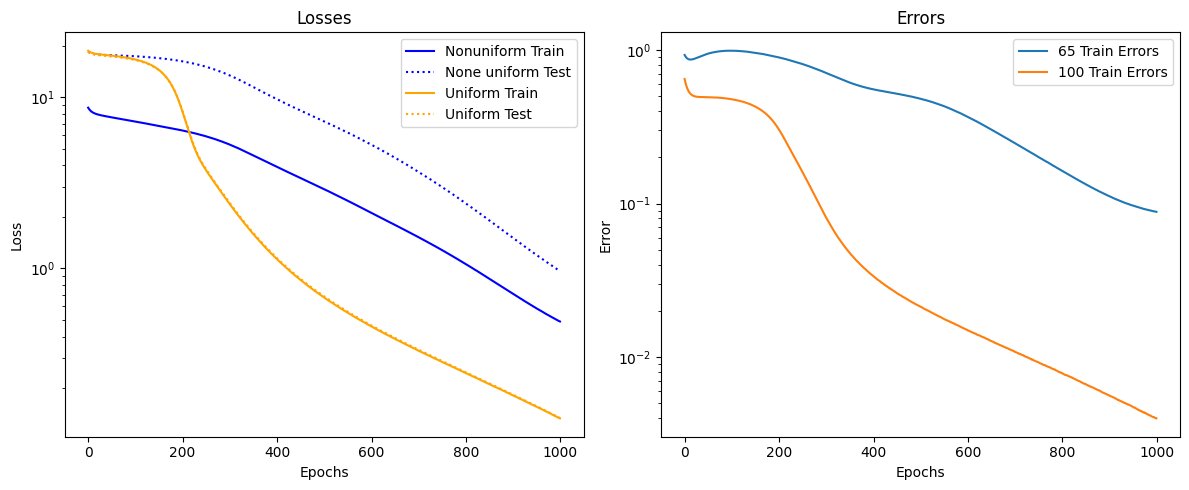

In [28]:
# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First subplot for losses
ax1.semilogy(out_65['train_losses'],color='blue', label='Nonuniform Train')
ax1.semilogy(out_65['test_losses'], color='blue',linestyle='dotted', label='None uniform Test')
ax1.semilogy(out_100['train_losses'], color='orange',label='Uniform Train')
ax1.semilogy(out_100['test_losses'], color='orange',linestyle='dotted', label='Uniform Test')
ax1.set_title('Losses')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Second subplot for errors
ax2.semilogy(out_65['train_errors'], label='65 Train Errors')
ax2.semilogy(out_100['train_errors'], label='100 Train Errors')
ax2.set_title('Errors')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Error')
ax2.legend()

# Show the plot
plt.tight_layout()
plt.show()

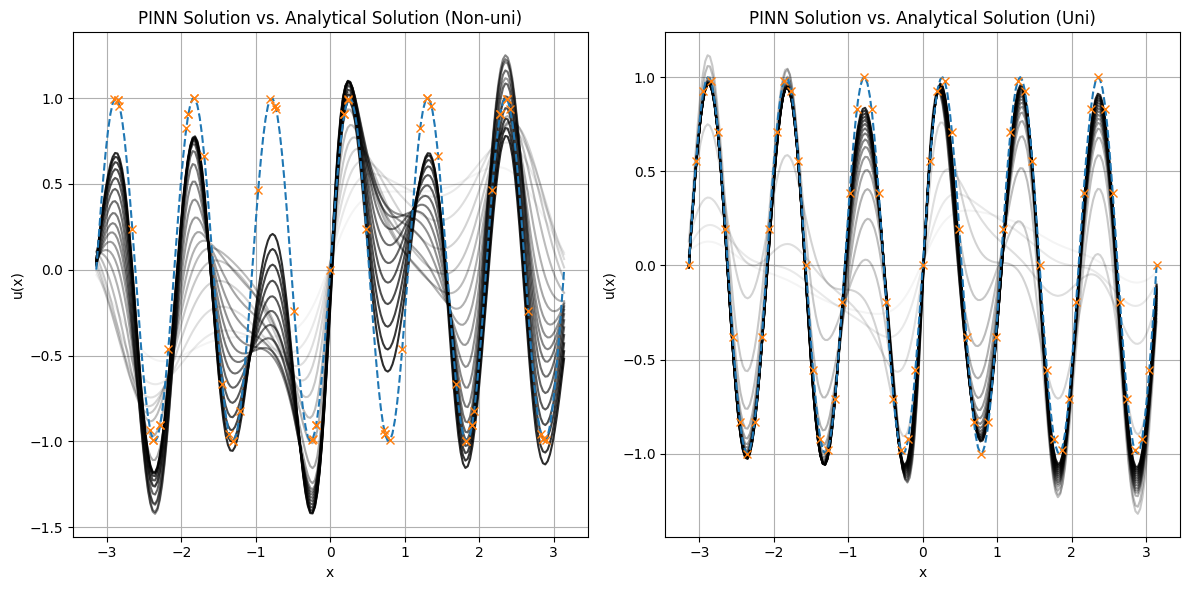

In [29]:
# Create a figure with subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Evaluate for out_65
num_test_points = 200
x_test = jnp.linspace(-jnp.pi, jnp.pi, num_test_points).reshape(-1, 1)
u_analytical = true(x_test)

all_params = out_65['params'][0:30]
for i, params in enumerate(all_params):
    u_pred = out_65['model'].apply({'params': params}, x_test)
    ax1.plot(x_test, u_pred, color='black', alpha=i / (len(all_params) + 3))

ax1.plot(x_test, u_analytical, '--', label='Analytical Solution')
train = generate_nonuniform_dataset(65)
ax1.plot(train, true(train), 'x')
ax1.set_xlabel('x')
ax1.set_ylabel('u(x)')
ax1.set_title('PINN Solution vs. Analytical Solution (Non-uni)')
ax1.grid(True)
# ax1.set_ylim((-3, 3))

# Evaluate for out_100
x_test = jnp.linspace(-jnp.pi, jnp.pi, num_test_points).reshape(-1, 1)
u_analytical = true(x_test)

all_params = out_100['params'][0:30]
for i, params in enumerate(all_params):
    u_pred = out_100['model'].apply({'params': params}, x_test)
    ax2.plot(x_test, u_pred, color='black', alpha=i / (len(all_params) + 3))

ax2.plot(x_test, u_analytical, '--', label='Analytical Solution')
train = generate_uniform_dataset(65)
ax2.plot(train, true(train), 'x')
ax2.set_xlabel('x')
ax2.set_ylabel('u(x)')
ax2.set_title('PINN Solution vs. Analytical Solution (Uni)')
ax2.grid(True)

# Show the plot
plt.tight_layout()
plt.show()